In [1]:
import sys
sys.path.append(r"C:\Users\saksh\OneDrive - University of Keele\Desktop\Ecommerce_project")

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from src.data.loader import load_data
from src.features.engineering import add_engineered_features
from src.config.settings import load_config

config = load_config()


In [2]:
df = load_data()
df = add_engineered_features(df)
df = pd.get_dummies(df, columns=config['categorical_columns'])

X = df.drop(config['target_column'], axis=1)
y = df[config['target_column']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=config['test_size'], random_state=config['random_seed'])



2026-08-22 05:30:15,498 | INFO | src.data.loader | Data loaded successfully from C:/Users/saksh/OneDrive - University of Keele/Desktop/Ecommerce_project/dataset/ecommerce_sessions.csv.
2026-08-22 05:30:15,504 | INFO | src.data.loader | All expected columns are present in the dataset.
2026-08-22 05:30:15,532 | INFO | src.features.engineering | Engineered features added to the DataFrame.


<Axes: title={'center': 'Top 15 Feature Importances'}>

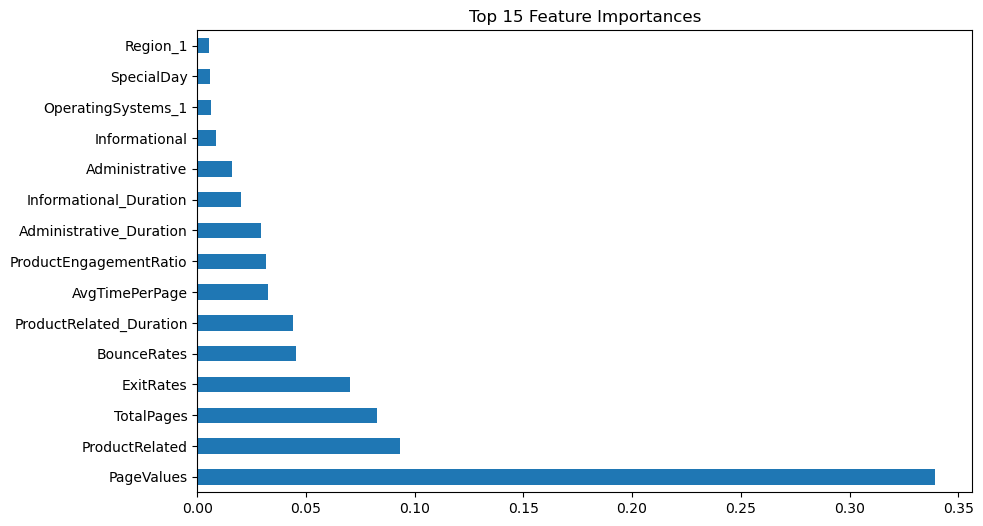

In [3]:
rf = RandomForestClassifier(n_estimators= 100, random_state=config['random_seed'])
rf.fit(X_train, y_train)

feature_imp = pd.Series(rf.feature_importances_, index=X_train.columns)
top_15_features = feature_imp.nlargest(15)

top_15_features.plot(kind='barh', figsize=(10, 6), title='Top 15 Feature Importances')


<Axes: title={'center': 'Top 15 Permutation Feature Importances'}>

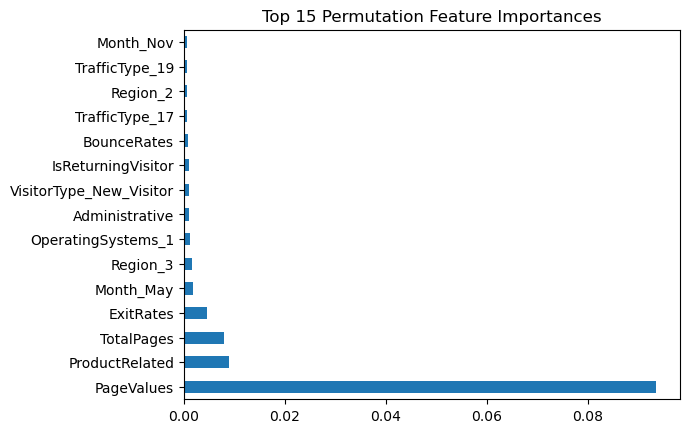

In [4]:
perm_results = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=config['random_seed'])
perm_imp = pd.Series(perm_results.importances_mean, index=X_test.columns)
top_15_perm_features = perm_imp.nlargest(15)
top_15_perm_features.plot(kind='barh', title='Top 15 Permutation Feature Importances')